<h4>Assessment 2 - Brief</h4>

* Analytic question formulation
* Data wrangling
* Data preparation and sampling
* Descriptive statistics
* Inferential statistics (Confidence interval)
* Inferential statistics (Two-sample t-Test)

Question: Likelihood of goalkeeper saving goals during the world cup (goalkeeper that played in world cup 2026)

Potential other analysis:
- inside the penalty area
- outside the penalty area

Note: 
- remove Rank and replace with player ID
- Does sample = population data
- We are to work with sample data calculate mean and proportion

Sample size = 61 goalkeepers (min 30-40 players)
1. give each player an id - From player csv
2. Randomly choose players - Can be randomly selected with python code
3. Review the glossary def for actions inside pa and actions outside pa
4. Calculate confidence interval - CI - Inferential stat
6. What confidence level - 95%
7. Sample T test - Compaire to previous years 2022 world cup
    - Use for hypothsis testing - Inferential stat (two-sample T test)
8. Create powerpoint of analysis of Goalkeeper saves during world cup 2026


<h3>Goalkeeping Definitions</h3>

<h3>Clean Sheets</h3>
- Matches in which a team does not concede any goals, typically used to evaluate defensive and goalkeeper performance.

<h3>Goals Conceded</h3>
- Goals Conceded indicate the total number of goals a team has allowed their opponent to score.

<h3>Goalkeeper Goal Preventions</h3>
- The total number of successful goalkeeping actions that prevent a goal from being scored, including any attempt at goal stopped or deflected by the goalkeeper using any part of the body within the rules.

<h3>Goalkeeper Actions Inside the Penalty Area</h3>
- All defensive interventions made by the goalkeeper within their own penalty area, including saves, punches, and claims.

<h3>Goalkeeper Actions Outside the Penalty Area</h3>
- All defensive interventions made by the goalkeeper outside their penalty area, often involving tackles or clearances.
<br>

In [1]:
import pandas as pd
import numpy as np
import statistics as stats
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import scipy.stats as st
import math
import statsmodels.stats.proportion as stmp
import statsmodels.stats.weightstats as stm

ModuleNotFoundError: No module named 'matplotlib'

In [ ]:
goalkeeper = pd.read_csv("goalkeeper.csv")

In [ ]:
# Variance
gk_save_var = np.array(goalkeeper["Goalkeeper_Saves"])
gk_saves_square = gk_save_var.var(ddof=1) # sample var - degree of freedon (ddof)
gk_save_sigma_square = gk_save_var.var() # popluation var - no ddof required

print("variance s square: ", gk_saves_square)
print("var sigma square: ", gk_save_sigma_square)

variance s square:  39.27814207650272
var sigma square:  38.63423810803546


In [ ]:
gk_inside_var = np.array(goalkeeper["Goalkeeper_Actions_inside_PenaltyArea"])
gk_inside_square = gk_inside_var.var(ddof=1) # sample var - degree of freedon (ddof)
gk_inside_sigma_square = gk_inside_var.var() # popluation var - no ddof required

print("variance s square: ", gk_inside_square)
print("var sigma square: ", gk_inside_sigma_square)

In [ ]:
# standard deviation
s = gk_save_var.std(ddof=1) # sample standard dev
sigma = gk_save_var.std()
print("standard deviation: %.2f" % s)
print("stad dev population: ", sigma)

standard deviation: 6.27
stad dev population:  6.215644625301181


In [ ]:
percentile25th = (goalkeeper["Goalkeeper_Saves"]).quantile(0.25)
percentile50th = (goalkeeper["Goalkeeper_Saves"]).quantile(0.50) # check if same as median value = yes 11.0
percentile75th = (goalkeeper["Goalkeeper_Saves"]).quantile(0.75)
print(percentile25th)
print(percentile50th)
print(percentile75th)

player = np.array(goalkeeper["Player"])
savesgk = np.array(goalkeeper["Goalkeeper_Saves"])

7.0
11.0
15.0


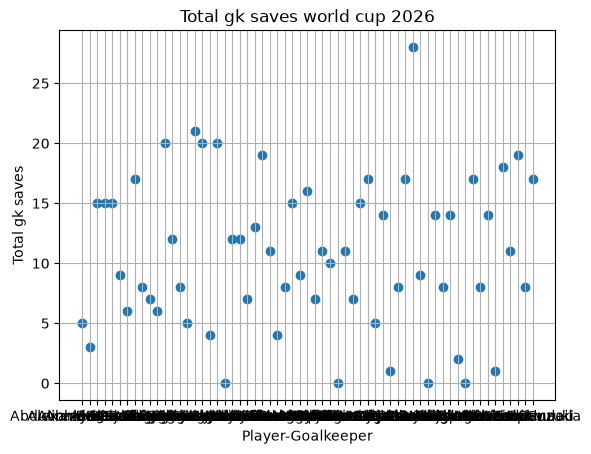

In [ ]:
plt.scatter(player, savesgk)
plt.title("Total gk saves world cup 2026")
plt.xlabel("Player-Goalkeeper")
plt.ylabel("Total gk saves")
plt.grid()
plt.show()

In [ ]:
# GK saves
gk_saves = goalkeeper.Goalkeeper_Saves.values
# GK saves inside the penalty area
gk_saves_ipa = goalkeeper.Goalkeeper_Actions_inside_PenaltyArea.values
# GK saves oudise penalty area
gk_saves_opa = goalkeeper.Goalkeeper_Actions_outside_PenaltyArea.values
print(gk_saves)
print(gk_saves_ipa)
print(gk_saves_opa)

[ 5  3 15 15 15  9  6 17  8  7  6 20 12  8  5 21 20  4 20  0 12 12  7 13
 19 11  4  8 15  9 16  7 11 10  0 11  7 15 17  5 14  1  8 17 28  9  0 14
  8 14  2  0 17  8 14  1 18 11 19  8 17]
[ 55  43  85  75  67  75  51  57  55  57  26 114  80  34  25  81 111  41
 100   3  68  54  51  56 133  42  22  31  83  34 124  61  60  58  21  97
  49 108  86  53 119  26  92 107 141  48  14  91  57  72   7   7 110  55
 120  27 136  84 112  70  78]
[ 44  36  74  65  59  64  44  54  47  54  22  93  68  25  22  72  97  34
  88   3  63  46  45  48 110  34  20  30  70  32 103  45  52  48  17  88
  40  86  78  45 105  20  70  93 124  42  13  76  46  59   5   5  90  46
  93  21 102  68  91  56  64]


Text(0, 0.5, 'Goalkeeper')

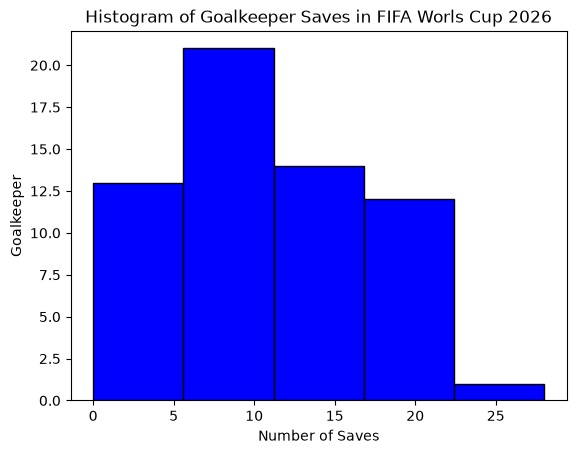

In [ ]:
# set up the histogram parameters for goalkeeper saves
max_val = gk_saves.max()
min_val = gk_saves.min()
the_range = max_val - min_val
bin_width = 5 # smaller bin width gives more detail, but can be noisy
bin_count = int(the_range / bin_width)

# create the histogram for goalkeeper saves
plt.hist(gk_saves, bins=bin_count, range=(min_val, max_val), color='blue', edgecolor='black')
plt.title('Histogram of Goalkeeper Saves in FIFA Worls Cup 2026')
plt.xlabel('Number of Saves')
plt.ylabel('Goalkeeper')

Text(0, 0.5, 'add text here')

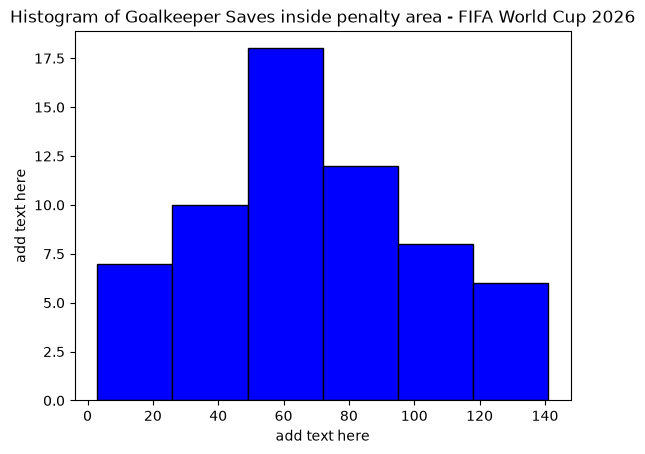

In [ ]:
# set up the histogram parameters for goalkeeper saves inside penalty area
max_val_ipa = gk_saves_ipa.max()
min_val_ipa = gk_saves_ipa.min()
the_range_ipa = max_val_ipa - min_val_ipa
bin_width_ipa = 20 # smaller bin width gives more detail, but can be noisy
bin_count_ipa = int(the_range_ipa / bin_width_ipa)

# create the histogram for goalkeeper saves inside penalty area
plt.hist(gk_saves_ipa, bins=bin_count_ipa, range=(min_val_ipa, max_val_ipa), color='blue', edgecolor='black')
plt.title('Histogram of Goalkeeper Saves inside penalty area - FIFA World Cup 2026')
plt.xlabel('add text here')
plt.ylabel('add text here')

Text(0, 0.5, 'add text here')

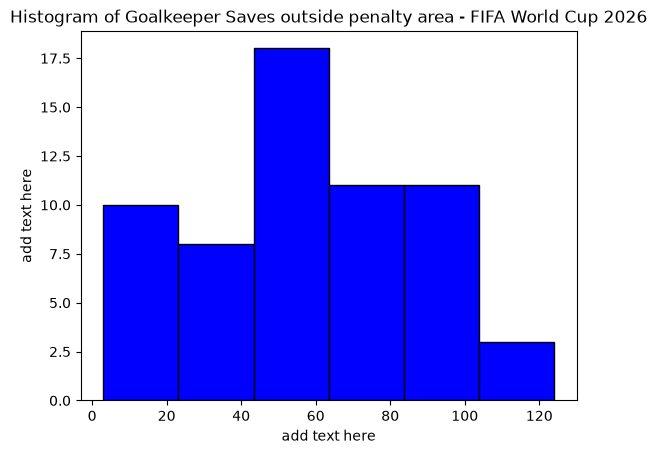

In [ ]:
# set up the histogram parameters for goalkeeper saves outside penalty area
max_val_opa = gk_saves_opa.max()
min_val_opa = gk_saves_opa.min()
the_range_opa = max_val_opa - min_val_opa
bin_width_opa = 20 # smaller bin width gives more detail
bin_count_opa = int(the_range_opa / bin_width_opa)

# create the histogram for goalkeeper saves outside penalty area
plt.hist(gk_saves_opa, bins=bin_count_opa, range=(min_val_opa, max_val_opa), color='blue', edgecolor='black')
plt.title('Histogram of Goalkeeper Saves outside penalty area - FIFA World Cup 2026')
plt.xlabel('add text here')
plt.ylabel('add text here')

<table>
<tr>
<th>Goalkeeper_Saves</th>
<th>Goalkeeper_Actions_inside_PenaltyArea</th>
<th>Goalkeeper_Actions_outside_PenaltyArea</th>
</tr>
<tr>
<td>count 61.000000<br>mean 10.704918<br>std 6.267228<br>min 0.00<br>IQR 25% 7.000000<br>IQR 50% 11.000000<br>IQR 75% 15.000000<br>max 28.000000</td>
<td>count 61.000000<br>mean 67.196721<br>std 34.791196<br>min 3.0000<br>IQR 25% 43.000000<br>IQR 50% 60.000000<br>IQR 75% 91.000000<br>max 141.000000</td>
<td>count 61.000000<br>mean 56.622951<br>std 29.013310<br>min 3.000000<br>min 3.000000<br>IQR 25% 36.000000<br>IQR 50% 54.000000<br>IQR 75% 76.000000<br>max 124.000000</td>
</tr>
</table>

In [ ]:
# create mean, median and sample size values for goalkeeper saves, inside penalty area and outside penalty area
gk_s_mean = goalkeeper["Goalkeeper_Saves"].mean()
gk_ipa_mean = goalkeeper["Goalkeeper_Actions_inside_PenaltyArea"].mean()
gk_opa_mean = goalkeeper["Goalkeeper_Actions_outside_PenaltyArea"].mean()
gk_s_median = goalkeeper["Goalkeeper_Saves"].median()
gk_ipa_median = goalkeeper["Goalkeeper_Actions_inside_PenaltyArea"].median()
gk_opa_median = goalkeeper["Goalkeeper_Actions_outside_PenaltyArea"].median()
gk_s_sample_size = len(goalkeeper["Goalkeeper_Saves"])
gk_ipa_sample_size = len(goalkeeper["Goalkeeper_Actions_inside_PenaltyArea"])
gk_opa_sample_size = len(goalkeeper["Goalkeeper_Actions_outside_PenaltyArea"])

In [ ]:
# calculation confidence interval goalkeeper saves
ci_low, ci_upp = stm._zconfint_generic(gk_s_mean, gk_s_sample_size / math.sqrt(gk_s_sample_size), alpha=0.05, alternative='two-sided') # 95% confidence interval aplpha=0.05 or 5%
print("CI Lower gk saves: %.2f to %.2f" % (ci_low, ci_upp))

CI Lower gk saves: -4.60 to 26.01


In [ ]:
# calculation confidence interval goalkeeper saves inside penalty area
ci_low, ci_upp = stm._zconfint_generic(gk_ipa_mean, gk_ipa_sample_size / math.sqrt(gk_ipa_sample_size), alpha=0.05, alternative='two-sided') # 95% confidence interval aplpha=0.05 or 5%
print("CI Lower gk ipa: %.2f to %.2f" % (ci_low, ci_upp))

CI Lower gk ipa: 51.89 to 82.50


In [ ]:
# calculation confidence interval goalkeeper saves outside penalty area
ci_low, ci_upp = stm._zconfint_generic(gk_opa_mean, gk_opa_sample_size / math.sqrt(gk_opa_sample_size), alpha=0.05, alternative='two-sided') # 95% confidence interval aplpha=0.05 or 5%
print("CI Lower gk opa: %.2f to %.2f" % (ci_low, ci_upp))

CI Lower gk opa: 41.32 to 71.93


In [ ]:
import pandas as pd
from scipy import stats

# Extract the saves column
gk_savest_stat = goalkeeper["Goalkeeper_Saves"].values

# Hypothesized mean 
mu_0 = 10.70

# Compute t-statistic and p-value
t_stat, p_value = stats.ttest_1samp(gk_savest_stat, mu_0)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 0.006128876481186812
p-value: 0.9951302273130959


In [ ]:
gk_saves_t_stat = 0.006128876481186812
gk_saves_p_value = 0.9951302273130959

In [ ]:
# create sample from 2022
goalkeeper2022 = pd.read_csv("gkstats2022.csv")

In [ ]:
# create sample from goalkepper 2026 FIFA World Cup
sample_gk_t_test_2026 = goalkeeper.sample(n=30, random_state=42)   # randomly select 30 rows random_state=42 is a seed for the random number generator FIFA 2026
print(sample_gk_t_test_2026)

sample_gk_t_test_2026.describe()

                Player Team Position  Goalkeeper_Saves  \
0    Abduvohid Nematov  UZB       GK                 5   
5           Angus Gunn  SCO       GK                 9   
46      Oussama Benbot  ALG       GK                 0   
31        Manuel Neuer  GER       GK                 7   
13       Edouard Mendy  SEN       GK                 8   
55       Utkir Yusupov  UZB       GK                 1   
34         Matt Turner  USA       GK                 0   
49     Ronwen Williams  RSA       GK                14   
12   Dominik Livakovic  CRO       GK                12   
40     Mostafa Shoubir  EGY       GK                14   
33         Matt Freese  USA       GK                10   
59     Yazeed Abulaila  JOR       GK                 8   
16   Emiliano Martinez  ARG       GK                20   
3   Alireza Beiranvand  IRN       GK                15   
53       Ugurcan Cakir  TUR       GK                 8   
17    Fernando Muslera  URU       GK                 4   
8       Benjam

,Goalkeeper_Saves,Goalkeeper_Actions_inside_PenaltyArea,Goalkeeper_Actions_outside_PenaltyArea,ID
count,30.000000,30.000000,30.000000,30.000000
mean,10.033333,63.966667,53.966667,2467.366667
std,6.840464,33.217656,28.787549,423.489240
min,0.000000,3.000000,3.000000,1802.000000
25%,6.250000,41.250000,34.000000,2071.000000
50%,8.500000,59.500000,51.000000,2538.500000
75%,14.000000,80.750000,68.000000,2886.500000
max,28.000000,141.000000,124.000000,3017.000000


In [ ]:
# create sample from goalkepper 2022 FIFA World Cup
sample_gk_t_test_2022 = goalkeeper2022.sample(n=30, random_state=42)   # randomly select 30 rows random_state=42 is a seed for the random number generator FIFA 2022
print(sample_gk_t_test_2022)

sample_gk_t_test_2022.describe()

                Player Position            Team  GoalsAgainst  \
24        Manuel Neuer       GK      de Germany             5   
13    Hossein Hosseini       GK      ir IR Iran             6   
8         Aymen Dahmen       GK      tn Tunisia             1   
25     Andries Noppert       GK  nl Netherlands             4   
4         Milan Borjan       GK       ca Canada             7   
40            Wéverton       GK       br Brazil             0   
19       Édouard Mendy       GK      sn Senegal             7   
39          Danny Ward       GK       wls Wales             5   
29     Jordan Pickford       GK     eng England             4   
6          Diogo Costa       GK     pt Portugal             6   
26     Guillermo Ochoa       GK       mx Mexico             3   
12     Wayne Hennessey       GK       wls Wales             1   
17      Steve Mandanda       GK       fr France             1   
9         Devis Epassy       GK     cm Cameroon             3   
15   Dominik Livaković   

,GoalsAgainst,GoalsAgainstPer90min,ShotsOnTarget_against,Saves2022,Save_percentage,CleanSheet,CleanSsheetPerc
count,30.000000,30.000000,30.000000,30.000000,29.000000,30.000000,29.000000
mean,3.800000,1.336000,11.700000,7.900000,64.665517,0.933333,26.389655
std,2.249904,0.970164,7.625502,6.104549,14.507025,1.014833,28.420570
min,0.000000,0.000000,0.000000,0.000000,33.300000,0.000000,0.000000
25%,2.000000,0.792500,6.000000,4.000000,58.300000,0.000000,0.000000
50%,4.000000,1.000000,10.500000,7.000000,66.700000,1.000000,20.000000
75%,5.750000,1.627500,16.500000,9.750000,75.000000,2.000000,50.000000
max,7.000000,4.790000,32.000000,25.000000,90.000000,3.000000,100.000000


In [ ]:
# 2026 sample values in numpy this is required to run py code in the notebook
sample = np.array(sample_gk_t_test_2026.Goalkeeper_Saves.values)

# compute mean and standard deviation of the sample
print("Computing the basic statistics ...")
x_bar = st.tmean(sample)
s = st.tstd(sample)
print("\t Sample mean: %.2f" % x_bar)
print("\t Sample std. dev.: %.2f" % s)

# perform one-sample t-test
# null hypothesis: population mean = 10.033333333333333
# alternative hypothesis: population mean > 10.033333333333333 (in the function below, note the argument 'greater')
t_stats, p_val = st.ttest_1samp(sample, 10.033333333333333, alternative='greater')
print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val <= 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")

Computing the basic statistics ...
	 Sample mean: 10.03
	 Sample std. dev.: 6.84

 Computing t* ...
	 t-statistic (t*): 0.00

 Computing p-value ...
	 p-value: 0.5000

 Conclusion:
	 We accept the null hypothesis.


In [ ]:
# 2022 sample values in numpy this is required to run py code in the notebook
sample2 = np.array(sample_gk_t_test_2022.Saves2022.values)

# compute mean and standard deviation of the sample2
print("Computing the basic statistics ...")
x_bar2 = st.tmean(sample2)
s2 = st.tstd(sample2)
print("\t Sample mean: %.2f" % x_bar2)
print("\t Sample std. dev.: %.2f" % s2)

# perform one-sample t-test
# null hypothesis: population mean = 7.9
# alternative hypothesis: population mean > 7.9 (in the function below, note the argument 'greater')
t_stats, p_val = st.ttest_1samp(sample2, 7.9, alternative='greater')
print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val <= 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")

Computing the basic statistics ...
	 Sample mean: 7.90
	 Sample std. dev.: 6.10

 Computing t* ...
	 t-statistic (t*): 0.00

 Computing p-value ...
	 p-value: 0.5000

 Conclusion:
	 We accept the null hypothesis.


In [ ]:
# two samples to be tested, instead of raw sample values.
# the basic statistics of sample 1 2026:
x_bar1 = sample.mean()
s1 = sample.std()
n1 = len(sample)

# the basic statistics of sample 2 2022:
x_bar2 = sample2.mean()
s2 = sample2.std()
n2 = len(sample2)

# perform two-sample t-test
# null hypothesis: mean of sample 1 = mean of sample 2
# alternative hypothesis: mean of sample 1 does not equal mean of sample 2 (two-sided test)
# note the argument equal_var=False, which assumes that two populations do not have equal variance
t_stats, p_val = st.ttest_ind_from_stats(x_bar1, s1, n1, x_bar2, s2, n2, equal_var=False, alternative='two-sided')
print("\n Computing t* ...")
print("\t t-statistic (t*): %.2f" % t_stats)

print("\n Computing p-value ...")
print("\t p-value: %.4f" % p_val)

print("\n Conclusion:")
if p_val <= 0.05:
    print("\t We reject the null hypothesis.")
else:
    print("\t We accept the null hypothesis.")


 Computing t* ...
	 t-statistic (t*): 1.30

 Computing p-value ...
	 p-value: 0.2001

 Conclusion:
	 We accept the null hypothesis.
